# Read the cleaned dataset without outliers from Phase 1 output

In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load the data
df = pd.read_csv('data_without_outliers.csv', encoding='utf-8')

# Random Forest Classification - New

Accuracy: 0.6987654320987654
Precision: 0.6503395450634636
Recall: 0.6987654320987654
F1-score: 0.6360911572807292


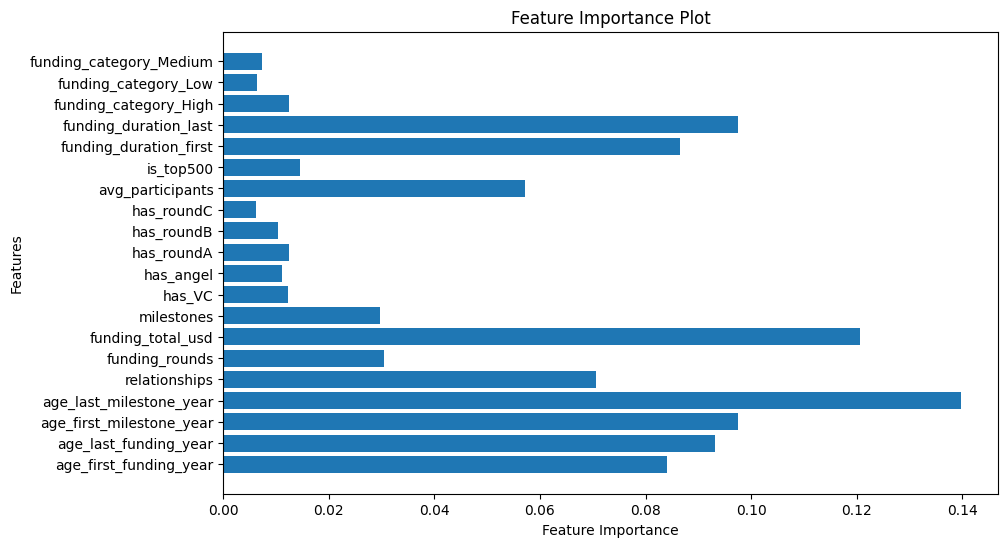

In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

df_copy = df.copy()

df_encoded_RF = pd.get_dummies(df_copy, columns=['funding_category'])

features = ['age_first_funding_year', 'age_last_funding_year', 'age_first_milestone_year',
            'age_last_milestone_year', 'relationships', 'funding_rounds', 'funding_total_usd', 'milestones',
            'has_VC', 'has_angel', 'has_roundA', 'has_roundB', 'has_roundC', 'avg_participants', 'is_top500',
            'funding_duration_first', 'funding_duration_last'] + list(df_encoded_RF.columns[df_encoded_RF.columns.str.startswith('funding_category_')])

target = 'status'

X = df_encoded_RF[features]
y = df_encoded_RF[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

importances = rf_classifier.feature_importances_

feature_names = X.columns

indices = importances.argsort()[::-1]


plt.figure(figsize=(10, 6))
plt.barh(features, rf_classifier.feature_importances_)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance Plot')
plt.show()

# Support Vector Machines(SVM) - InClass

Accuracy: 0.6641975308641975
Precision: 0.4411583600060966
Recall: 0.6641975308641975
F1-score: 0.5301754771586621


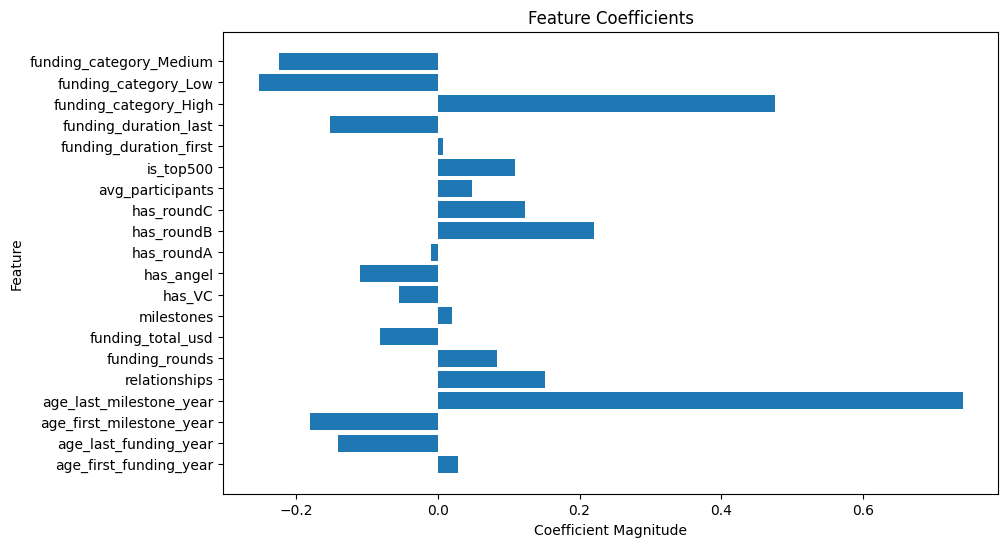

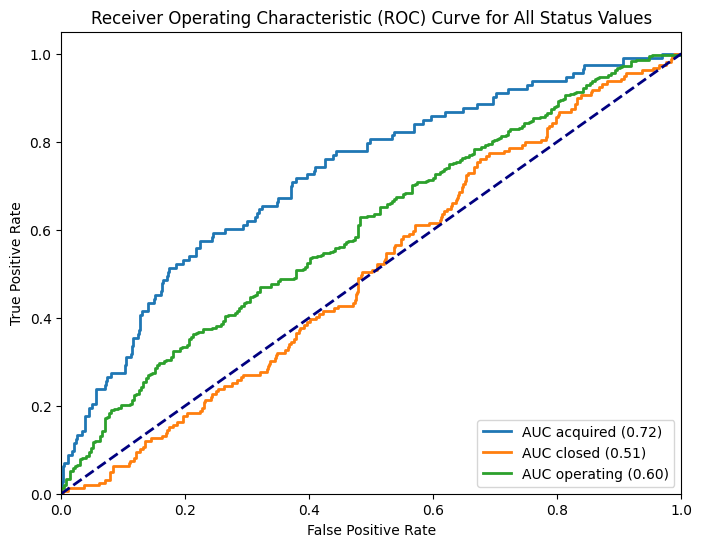

In [3]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Original data processing and SVM classification
df_copy = df.copy()

df_encoded_SVM = pd.get_dummies(df_copy, columns=['funding_category'])

features = ['age_first_funding_year', 'age_last_funding_year', 'age_first_milestone_year',
            'age_last_milestone_year', 'relationships', 'funding_rounds', 'funding_total_usd', 'milestones',
            'has_VC', 'has_angel', 'has_roundA', 'has_roundB', 'has_roundC', 'avg_participants', 'is_top500',
            'funding_duration_first', 'funding_duration_last'] + list(df_encoded_SVM.columns[df_encoded_SVM.columns.str.startswith('funding_category_')])

X = df_encoded_SVM[features]
y = df_encoded_SVM['status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_classifier = SVC(kernel='linear', random_state=50)

svm_classifier.fit(X_train_scaled, y_train)

y_pred = svm_classifier.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

plt.figure(figsize=(10, 6))
plt.barh(features, svm_classifier.coef_[0])
plt.xlabel('Coefficient Magnitude')
plt.ylabel('Feature')
plt.title('Feature Coefficients')
plt.show()

# ROC curve for each class
label_encoder = LabelEncoder()
y_binary = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=45)

svm_classifier = SVC(kernel='linear', probability=True, random_state=50)

plt.figure(figsize=(8, 6))
for i in range(len(label_encoder.classes_)):
    y_train_class = (y_train == i).astype(int)
    svm_classifier.fit(X_train_scaled, y_train_class)

    y_prob = svm_classifier.predict_proba(X_test_scaled)[:, 1]

    fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'AUC {label_encoder.classes_[i]} ({roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for All Status Values')
plt.legend(loc="lower right")
plt.show()

# Logistic Regression - InClass

Accuracy: 0.6851851851851852
Precision: 0.6635337350597368
Recall: 0.6851851851851852
F1-score: 0.5809812317868482


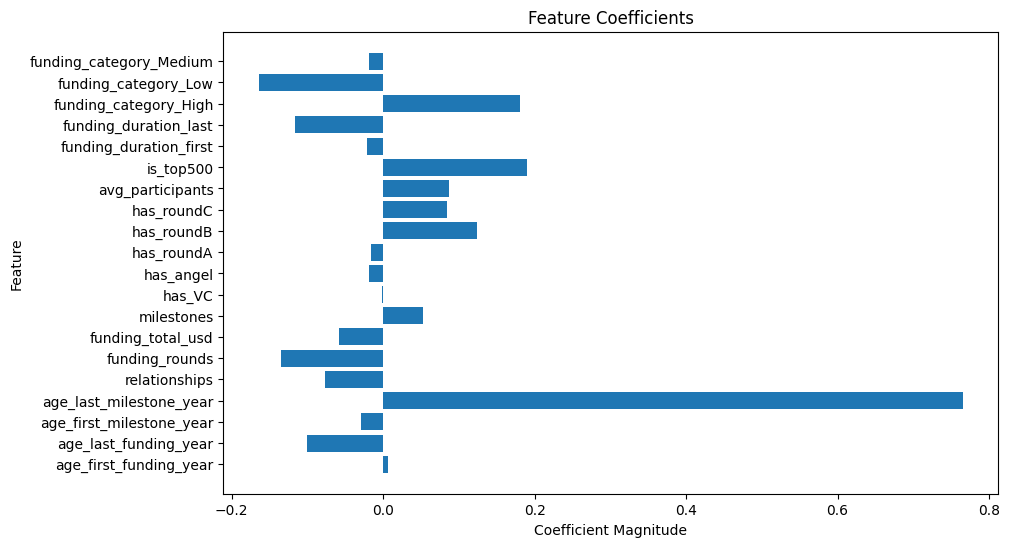

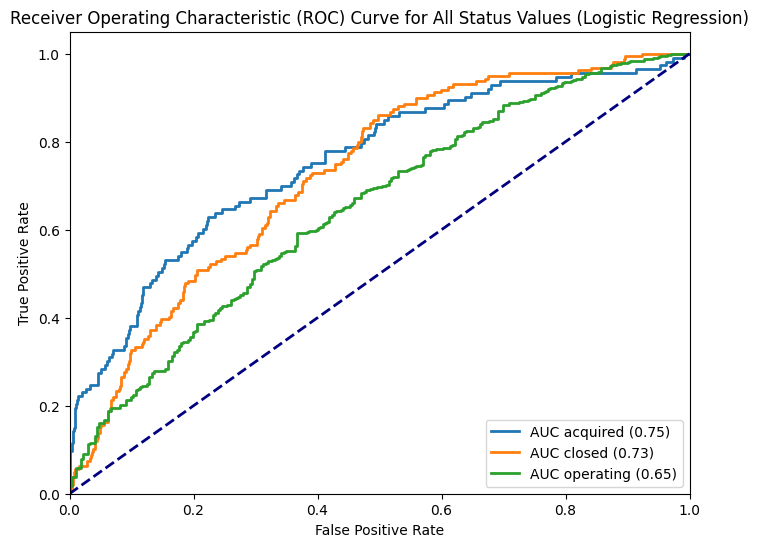

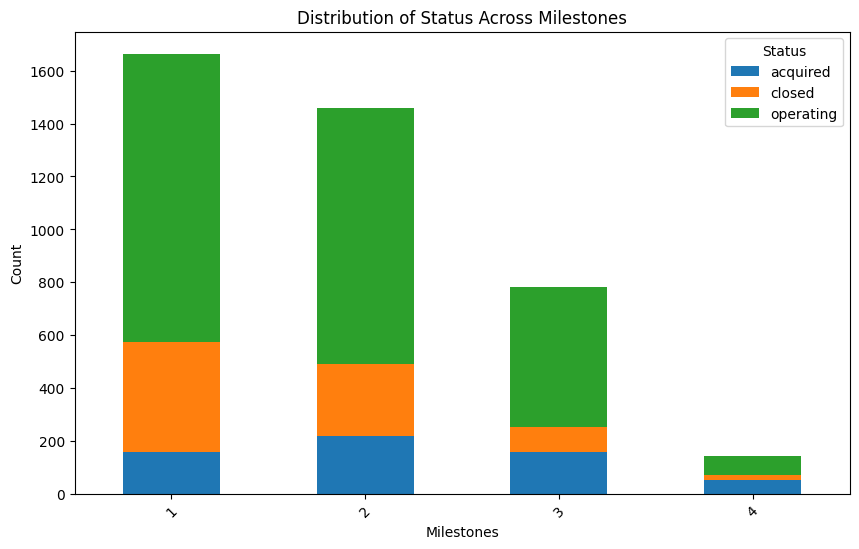

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder

df_encoded_LR = pd.get_dummies(df, columns=['funding_category'])

features = ['age_first_funding_year', 'age_last_funding_year', 'age_first_milestone_year',
            'age_last_milestone_year', 'relationships', 'funding_rounds', 'funding_total_usd', 'milestones',
            'has_VC', 'has_angel', 'has_roundA', 'has_roundB', 'has_roundC', 'avg_participants', 'is_top500',
            'funding_duration_first', 'funding_duration_last'] + list(df_encoded_LR.columns[df_encoded_LR.columns.str.startswith('funding_category_')])

X = df_encoded_LR[features]
y = df['status']

label_encoder = LabelEncoder()
y_binary = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=45)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

logistic_classifier = LogisticRegression(max_iter=1000, random_state=50)
logistic_classifier.fit(X_train_scaled, y_train)

y_pred = logistic_classifier.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

coefficients = logistic_classifier.coef_

plt.figure(figsize=(10, 6))
plt.barh(features, coefficients[0])
plt.xlabel('Coefficient Magnitude')
plt.ylabel('Feature')
plt.title('Feature Coefficients')
plt.show()

plt.figure(figsize=(8, 6))
for i in range(len(label_encoder.classes_)):
    y_train_class = (y_train == i).astype(int)
    logistic_classifier.fit(X_train_scaled, y_train_class)
    y_prob = logistic_classifier.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'AUC {label_encoder.classes_[i]} ({roc_auc:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for All Status Values (Logistic Regression)')
plt.legend(loc="lower right")
plt.show()

milestones_status_counts = df_encoded_LR.groupby(['milestones', 'status']).size().unstack(fill_value=0)
milestones_status_counts.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.xlabel('Milestones')
plt.ylabel('Count')
plt.title('Distribution of Status Across Milestones')
plt.legend(title='Status')
plt.xticks(rotation=45)
plt.show()

# Naive Bayes - InClass

Accuracy: 0.4246913580246914
Precision: 0.6238974043853766
Recall: 0.4246913580246914
F1-score: 0.42776220006032145


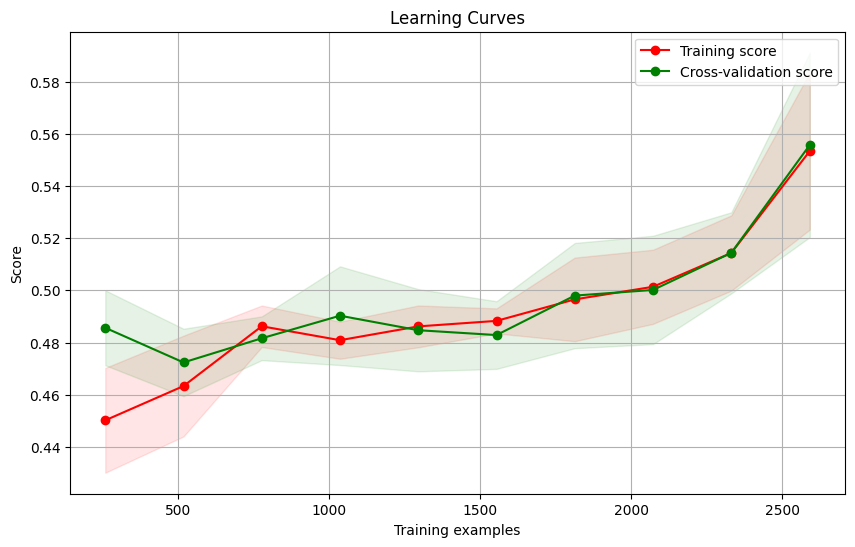

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np
from sklearn.preprocessing import StandardScaler

# Standardize features by removing the mean and scaling to unit variance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the Gaussian Naive Bayes classifier on the scaled features
nb_classifier = GaussianNB()
nb_classifier.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = nb_classifier.predict(X_test_scaled)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)


def plot_learning_curves(estimator, X, y):
    train_sizes, train_scores, valid_scores = learning_curve(
        estimator, X, y, train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy', cv=5)
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    valid_scores_mean = np.mean(valid_scores, axis=1)
    valid_scores_std = np.std(valid_scores, axis=1)
    
    plt.figure(figsize=(10, 6))
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="r")
    plt.fill_between(train_sizes, valid_scores_mean - valid_scores_std,
                     valid_scores_mean + valid_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
             label="Training score")
    plt.plot(train_sizes, valid_scores_mean, 'o-', color="g",
             label="Cross-validation score")
    
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    plt.title("Learning Curves")
    plt.legend(loc="best")
    plt.grid()
    plt.show()

plot_learning_curves(nb_classifier, X_train, y_train)

# KNN - InClass

Accuracy: 0.6012345679012345
Precision: 0.5593955351843622
Recall: 0.6012345679012345
F1-score: 0.5749279016711968


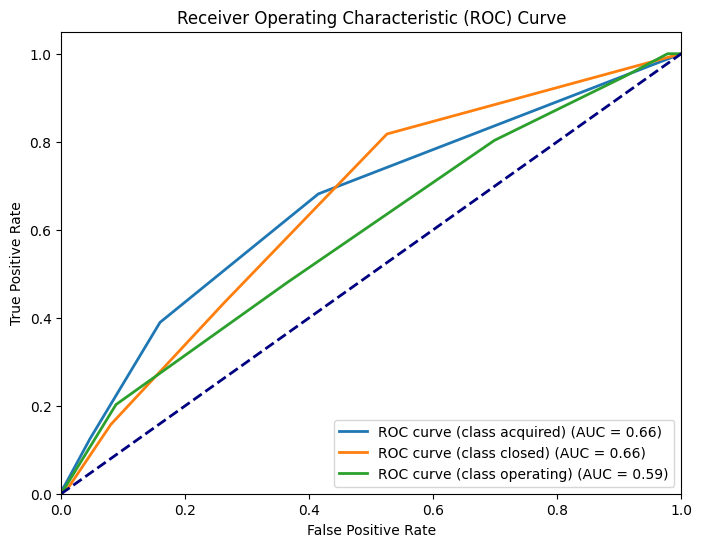

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

df_encoded_KNN = pd.get_dummies(df, columns=['funding_category'])

features = ['age_first_funding_year', 'age_last_funding_year', 'age_first_milestone_year',
            'age_last_milestone_year', 'relationships', 'funding_rounds', 'funding_total_usd', 'milestones',
            'has_VC', 'has_angel', 'has_roundA', 'has_roundB', 'has_roundC', 'avg_participants', 'is_top500',
            'funding_duration_first', 'funding_duration_last'] + list(df_encoded_KNN.columns[df_encoded_KNN.columns.str.startswith('funding_category_')])

X = df_encoded_KNN[features]
y = df['status']

label_encoder = LabelEncoder()
y_binary = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=45)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_classifier = KNeighborsClassifier()
knn_classifier.fit(X_train_scaled, y_train)

y_pred = knn_classifier.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_pred_bin = knn_classifier.predict_proba(X_test_scaled)

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(label_encoder.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
for i in range(len(label_encoder.classes_)):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'ROC curve (class {label_encoder.classes_[i]}) (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# XGBoost - InClass

Accuracy: 0.671604938271605
Precision: 0.6284189922990271
Recall: 0.671604938271605
F1-score: 0.6295641665072245


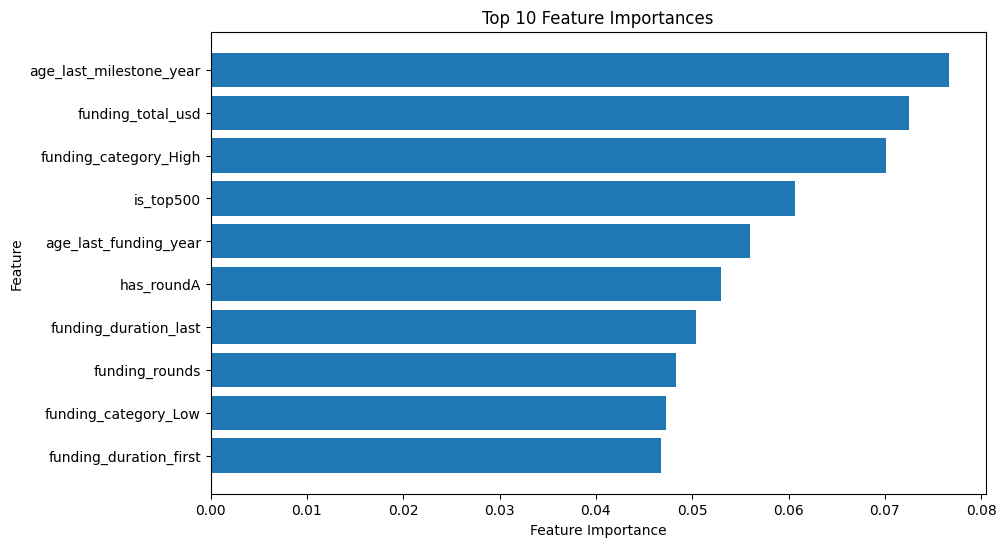

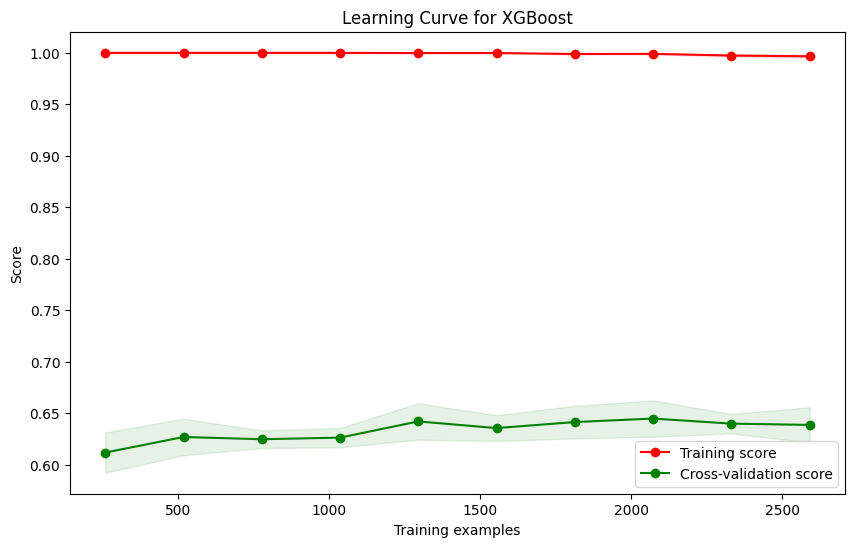

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier, plot_importance
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np

# Assuming df, X_train, X_test, y_train, y_test are defined

df_copy = df.copy()
df_encoded_XGB = pd.get_dummies(df_copy, columns=['funding_category'])

feature_labels = {
    'age_first_funding_year': 'Age at First Funding Year',
    'age_last_funding_year': 'Age at Last Funding Year',
    'age_first_milestone_year': 'Age at First Milestone Year',
    'age_last_milestone_year': 'Age at Last Milestone Year',
    'relationships': 'Relationships',
    'funding_rounds': 'Funding Rounds',
    'funding_total_usd': 'Funding Total (USD)',
    'milestones': 'Milestones',
    'has_VC': 'Has VC',
    'has_angel': 'Has Angel',
    'has_roundA': 'Has Round A',
    'has_roundB': 'Has Round B',
    'has_roundC': 'Has Round C',
    'avg_participants': 'Average Participants',
    'is_top500': 'Is Top 500',
    'funding_duration_first': 'Funding Duration First',
    'funding_duration_last': 'Funding Duration Last'
}

features = ['age_first_funding_year', 'age_last_funding_year', 'age_first_milestone_year',
            'age_last_milestone_year', 'relationships', 'funding_rounds', 'funding_total_usd', 'milestones',
            'has_VC', 'has_angel', 'has_roundA', 'has_roundB', 'has_roundC', 'avg_participants', 'is_top500',
            'funding_duration_first', 'funding_duration_last'] + list(df_encoded_XGB.columns[df_encoded_XGB.columns.str.startswith('funding_category_')])

target = 'status'

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

xgb_classifier = XGBClassifier(booster='gbtree', random_state=42)
xgb_classifier.fit(X_train, y_train_encoded)

y_pred_encoded = xgb_classifier.predict(X_test)
y_pred = label_encoder.inverse_transform(y_pred_encoded)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

importance = xgb_classifier.feature_importances_
feature_importance_dict = dict(zip(features, importance))
sorted_feature_importance = sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True)
top_features = [x[0] for x in sorted_feature_importance][:10]
top_importance = [x[1] for x in sorted_feature_importance][:10]

plt.figure(figsize=(10, 6))
plt.barh(top_features, top_importance)
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances')
plt.gca().invert_yaxis()
plt.show()

# Generate learning curve
train_sizes, train_scores, valid_scores = learning_curve(xgb_classifier, X_train, y_train_encoded, train_sizes=np.linspace(0.1, 1.0, 10), cv=5)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
valid_scores_mean = np.mean(valid_scores, axis=1)
valid_scores_std = np.std(valid_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1,
                 color="r")
plt.fill_between(train_sizes, valid_scores_mean - valid_scores_std,
                 valid_scores_mean + valid_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
         label="Training score")
plt.plot(train_sizes, valid_scores_mean, 'o-', color="g",
         label="Cross-validation score")
plt.xlabel("Training examples")
plt.ylabel("Score")
plt.title("Learning Curve for XGBoost")
plt.legend(loc="best")
plt.show()